In [35]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import random
from pytorch_lightning.loggers import TensorBoardLogger
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score
import json
import sys
sys.path.append('..')

import os
import torch
from torch.utils.data import TensorDataset, DataLoader
import torchvision.transforms as T
import warnings
import pickle
warnings.filterwarnings("ignore")

from src.data_assemble.wrap_data import *
from src.models.WindCNN import *
# from src.data_assemble.wrap_data import *

# %load_ext tensorboard
# %tensorboard --logdir lightning_logs/
torch.manual_seed(112)
random.seed(112)

In [37]:
path_to_data = os.path.join('..', 'data', 'nn_train')
st_split_dict = train_val_test_split(path_to_data, train = 0.5, val = 0.25, test = 0.25, verbose = True)
path_to_dump = os.path.join('..', 'data', 'nn_train')
X, y = extract_splitted_data(path_to_dump, st_split_dict)

{'Train': ['Краснодар, Круглик', 'Чертково', 'Гигант', 'Цимлянск(Волгодонск)', 'Готня', 'Анапа', 'Богородицкое-Фенино'], 'Val': ['Приморско-Ахтарск', 'Армавир', 'Таганрог'], 'Test': ['Сочи', 'Валуйки', 'Ремонтное', 'Красная Поляна', 'Туапсе']}


In [38]:
# a_file = open("../conf/conv_config.json", "r")
# json_object = json.load(a_file)
# a_file.close()
# print(json_object)

# json_object["in_channels"] = X['Train'].shape[1] # May be Edited

# a_file = open("../conf/conv_config.json", "w")
# json.dump(json_object, a_file)
# a_file.close()

In [39]:
batch_size = 1024
with open(os.path.join('..', 'conf', 'conv_config.json')) as fs:
    args = json.load(fs)

In [45]:
logger = TensorBoardLogger(save_dir='../logs/wind', name='windnet')
early_stop_callback = pl.callbacks.EarlyStopping(monitor="val_loss", min_delta=0.001, patience=5, verbose=False, mode="min")
trainer = pl.Trainer(max_epochs=5,
                    gpus=[0],
                    benchmark=True,
                    check_val_every_n_epoch=1,
                    # callbacks=[early_stop_callback]
)

dm = WindDataModule(X=X, y=y, batch_size=batch_size, downsample=False)
model = WindNetPL(args)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [46]:
trainer.fit(model, dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name         | Type            | Params
-------------------------------------------------
0 | net          | WindNet         | 22.4 K
1 | accuracy     | Accuracy        | 0     
2 | AUROC        | AUROC           | 0     
3 | precision_m  | Precision       | 0     
4 | recall       | Recall          | 0     
5 | F1           | F1Score         | 0     
6 | conf_matrix  | ConfusionMatrix | 0     
7 | stats_scores | StatScores      | 0     
8 | loss_f       | NLLLoss         | 0     
-------------------------------------------------
22.4 K    Trainable params
0         Non-trainable params
22.4 K    Total params
0.090     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


In [47]:
trainer.test(model, dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Testing: 0it [00:00, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_AUROC_step        0.5843079090118408
      test_acc_step         0.9916211366653442
      test_f1_step           0.989669144153595
        test_loss           0.6533397182309364
   test_precision_step      0.9916335344314575
    test_recall_step        0.9877126812934875
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6533397182309364,
  'test_acc_step': 0.9916211366653442,
  'test_recall_step': 0.9877126812934875,
  'test_AUROC_step': 0.5843079090118408,
  'test_precision_step': 0.9916335344314575,
  'test_f1_step': 0.989669144153595}]

In [48]:

with torch.no_grad():
    model_output = model(dm.transform(dm.X_test))

In [49]:
model_output

tensor([[  0.0000, -86.7951],
        [  0.0000, -87.2616],
        [  0.0000, -84.1721],
        ...,
        [  0.0000, -89.6657],
        [  0.0000, -89.2334],
        [  0.0000, -88.7633]], dtype=torch.float64)

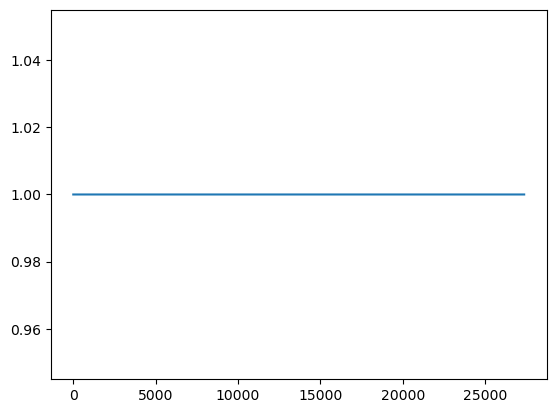

In [50]:
pred_prob = torch.exp(model_output)[:,0]
preds = torch.exp(model_output)[:].argmax(dim=1).cpu().numpy()
y_test = dm.y_test.cpu().numpy()
plt.plot(pred_prob)

In [16]:
print("acc = ", accuracy_score(y_test, preds))
print("recall = ", recall_score(y_test, preds))
print("prec = ", precision_score(y_test, preds))
print("auroc = ", roc_auc_score(y_test, pred_prob))

acc =  0.9943987823439878
recall =  0.0
prec =  0.0
auroc =  0.5
